In [1]:
# ДЗ
# 1. Подберите парамтеры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.
# 2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.
# 3. Применить алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.

In [2]:
import math
import numpy as np
import cv2
from scipy import ndimage
import matplotlib.pyplot as plt

In [3]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image = cv2.imread('palm_1.jpg')
image_pl = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_gray_pl = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [13]:
def homo_average(img, mask, point, T):
    av_val = img[mask > 0].sum() / np.count_nonzero(img[mask > 0])                                                        
    if abs(av_val - img[point]) <= T:
        return True
    return False

def region_growing(image, seed_point, homo_fun, r, T):
    mask = np.zeros(image.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    while count > 0:
        count = 0
        local_mask = np.zeros(image.shape, np.uint8)
        for i in range(r, image.shape[0] - r):
            for j in range(r, image.shape[1] - r):
                if mask[i,j] == 0 and mask[i - r:i + r, j-r: j+r].sum() > 0:
                    if homo_fun(image, mask, (i,j), T):
                        local_mask[i,j] = 1
        count = np.count_nonzero(local_mask)
        mask += local_mask
    return mask * 255

<h1>1. Подбор параметров алгоритма разрастания регионов для выделения всего участка газона.</h1>

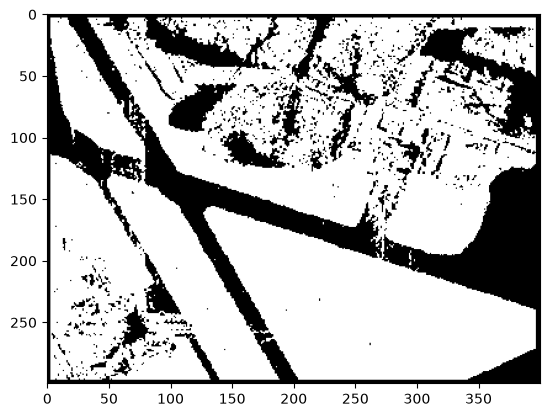

In [14]:
seed_point = (250, 250)
mask1 = region_growing(image_gray, seed_point, homo_average, 3, 32)
plt.imshow(mask1, cmap="gray")

<h1>2. Реализуйте вычисление критерия однородности, отличного от представленного</h1>

In [15]:
def homo_min_max(img, mask, point, T):
    region_pixels = img[mask > 0]
    new_pixel_val = img[point]
    if region_pixels.size == 0:
        return True
    current_min = region_pixels.min()
    current_max = region_pixels.max()

    new_min = min(current_min, new_pixel_val)
    new_max = max(current_max, new_pixel_val)
    if (new_max - new_min) <= T:
        return True
    return False

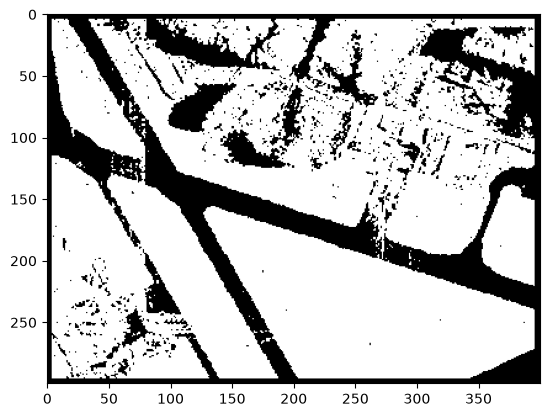

In [16]:
mask_min_max = region_growing(image_gray, seed_point, homo_min_max, 4, 70)
plt.imshow(mask_min_max, cmap="gray")
plt.show()

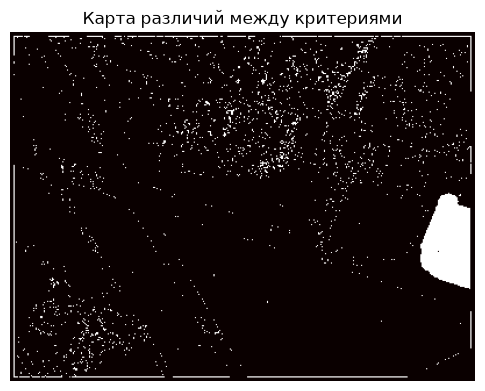

In [20]:
difference_mask = cv2.absdiff(mask1, mask_min_max)
plt.figure(figsize=(6, 5))
plt.imshow(difference_mask, cmap='hot')
plt.title("Карта различий между критериями")
plt.axis('off')
plt.show()

<h4>Реализован алгоритм вычисления критерия однородности на основе динамического диапазона яркости</h4>
Он обеспечивает более строгую и монолитную заливку. Он критичен к экстремумам, поэтому его границы получаются более резкими и геометрически точными. Он четко локализует газон в пределах физических границ. Данный алгоритм справился с задачей быстрее. а также выделил участок газона, который не выделили homo_average.

<h1>3. Алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.</h1>

Text(0.5, 1.0, 'Исходное изображение')

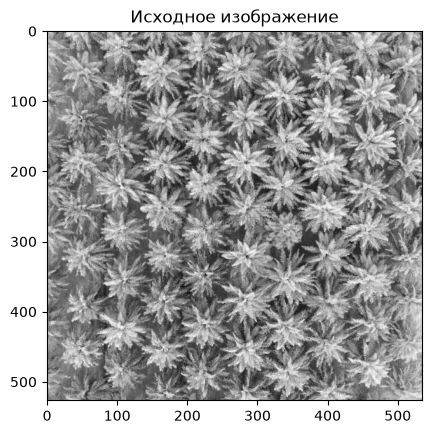

In [4]:
plt.imshow(image_gray_pl, cmap='gray')
plt.title('Исходное изображение')

Text(0.5, 1.0, 'После размытия Гаусса')

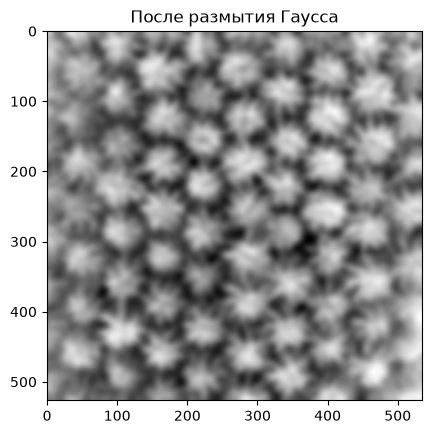

In [9]:
blurred = cv2.GaussianBlur(image_gray_pl, (31, 31), 0)
plt.imshow(blurred, cmap='gray')
plt.title('После размытия Гаусса')

Text(0.5, 1.0, 'Бинаризация')

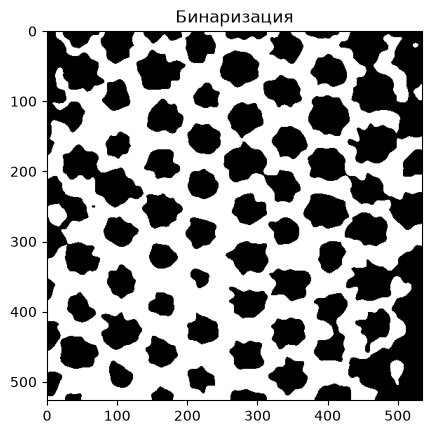

In [10]:
ret, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
plt.imshow(thresh, cmap='gray')
plt.title('Бинаризация')

Text(0.5, 1.0, 'Distance Transform')

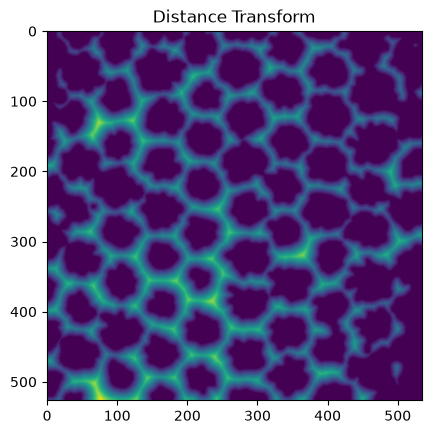

In [11]:
dist_transform = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
local_maxima = ndimage.maximum_filter(dist_transform, size=20, mode='constant')
plt.imshow(dist_transform)
plt.title('Distance Transform')

Text(0.5, 1.0, 'Найдено деревьев: 85')

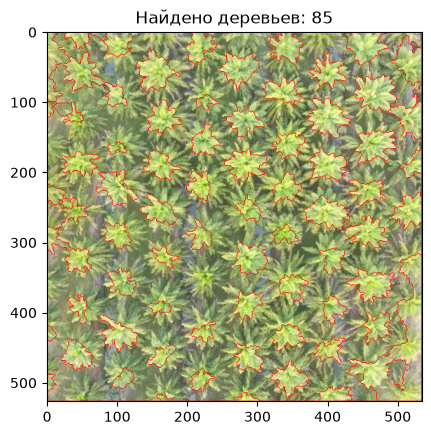

In [12]:
ret, sure_fg = cv2.threshold(dist_transform, 0.1 * dist_transform.max(), 255, cv2.THRESH_BINARY)
sure_fg = sure_fg.astype(np.uint8)
ret, markers = cv2.connectedComponents(sure_fg)
markers[dist_transform == local_maxima] = 1
markers = ndimage.label(markers)[0]  
markers = cv2.watershed(image_pl, markers.astype(np.int32))

num_trees = len(np.unique(markers)) - 1
segmented_image = image_pl.copy()
segmented_image[markers == -1] = [255, 0, 0]  
plt.imshow(segmented_image)
plt.title(f'Найдено деревьев: {num_trees}')